In [1]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# Téléchargement automatique
heart_disease = fetch_ucirepo(id=45)
X = heart_disease.data.features
y = heart_disease.data.targets

df = pd.concat([X, y], axis=1)
df.columns = ['age','sex','cp','trestbps','chol','fbs','restecg',
               'thalach','exang','oldpeak','slope','ca','thal','target']

# Binariser la cible (0 = pas malade, 1 = malade)
df['target'] = (df['target'] > 0).astype(int)

print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


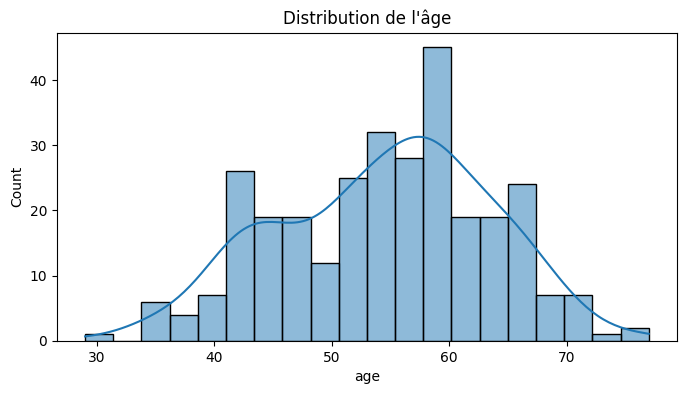

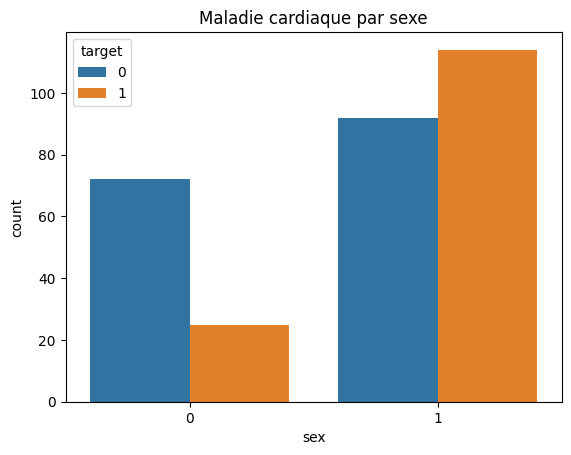

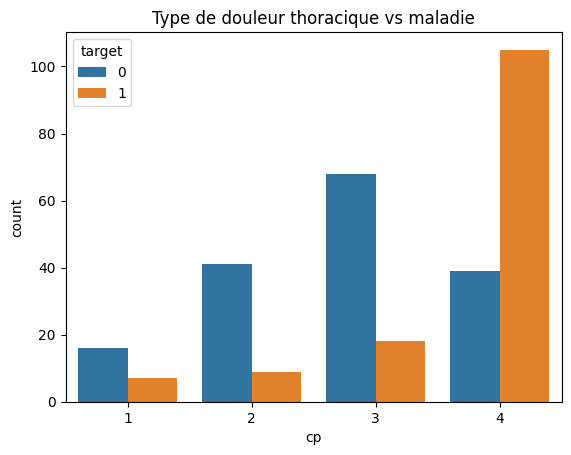

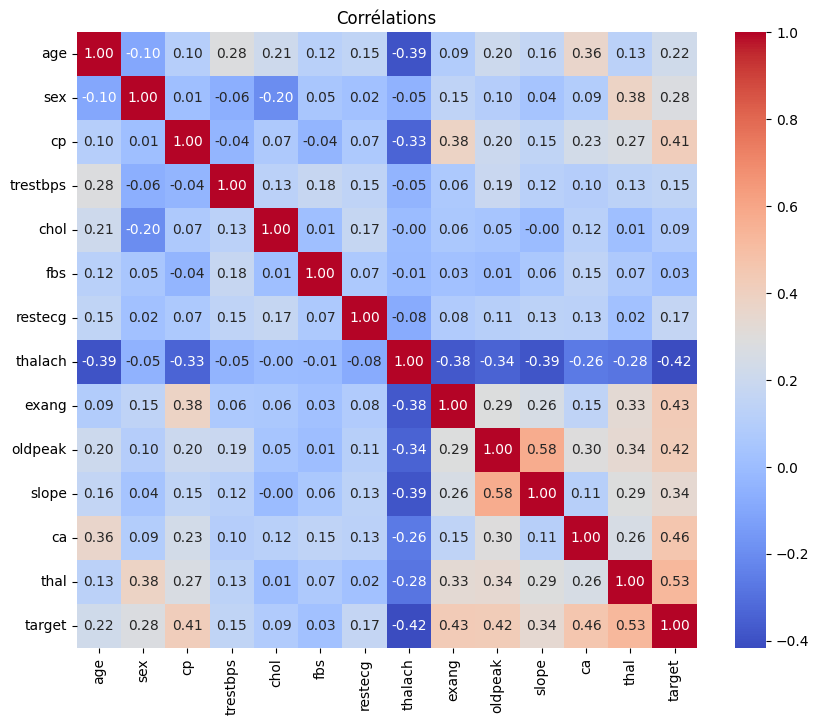

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution de l'âge
plt.figure(figsize=(8,4))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Distribution de l'âge")
plt.show()

# Maladie cardiaque selon le sexe
sns.countplot(data=df, x='sex', hue='target')
plt.title("Maladie cardiaque par sexe")
plt.show()

# Type de douleur thoracique vs target
sns.countplot(data=df, x='cp', hue='target')
plt.title("Type de douleur thoracique vs maladie")
plt.show()

# Valeurs moyennes par groupe
df.groupby('target')[['trestbps','chol','thalach']].mean()

# Matrice de corrélation
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Corrélations")
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# Traitement des valeurs manquantes
df = df.dropna()

X = df.drop('target', axis=1)
y = df['target']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Normalisation (important pour LR, KNN, SVM)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Définition des modèles
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN':                 KNeighborsClassifier(),
    'SVM':                 SVC(probability=True),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'AdaBoost':            AdaBoostClassifier(random_state=42)
}

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

results = []

for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred  = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:,1]

    results.append({
        'Modèle':    name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 3),
        'Précision': round(precision_score(y_test, y_pred), 3),
        'Rappel':    round(recall_score(y_test, y_pred), 3),
        'F1-Score':  round(f1_score(y_test, y_pred), 3),
        'AUC-ROC':   round(roc_auc_score(y_test, y_proba), 3),
    })

df_results = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False)
print(df_results.to_string(index=False))

             Modèle  Accuracy  Précision  Rappel  F1-Score  AUC-ROC
                SVM     0.850      0.880   0.786     0.830    0.954
Logistic Regression     0.833      0.846   0.786     0.815    0.950
                KNN     0.883      0.920   0.821     0.868    0.949
      Random Forest     0.867      0.885   0.821     0.852    0.941
           AdaBoost     0.850      0.852   0.821     0.836    0.911
      Decision Tree     0.683      0.680   0.607     0.642    0.679
